# Workshop 3

## 1. Binomial to Poisson

The sample size \(n\)  should be equal to or larger than \(20\) and the probability of a single success, \(p\), should be smaller than or equal to \(0.05\). If \(n > 100\), the approximation is excellent if \(np\)  is also less than 10. Verify it here!

1.0


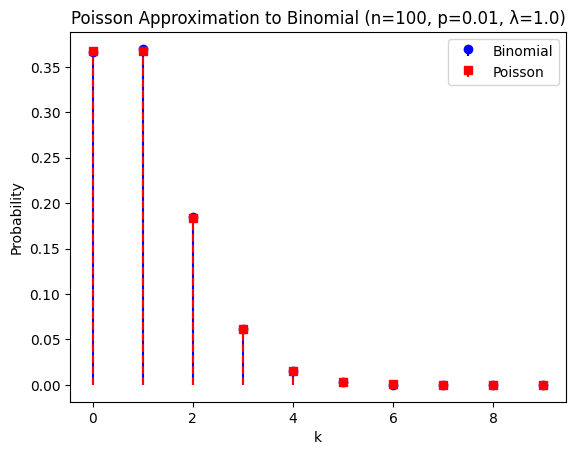

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, poisson

# Parameters
n = 100      # large number of trials
p = 0.01     # small probability
lam = n * p  # lambda for Poisson
print(lam)

# Range of k values
k = np.arange(0, 10)

# Compute probabilities
binomial_probs = binom.pmf(k, n, p)
poisson_probs = poisson.pmf(k, lam)

# Plot comparison
plt.stem(k, binomial_probs, linefmt='b-', markerfmt='bo', basefmt=" ", label="Binomial")
plt.stem(k, poisson_probs, linefmt='r--', markerfmt='rs', basefmt=" ", label="Poisson")

plt.xlabel("k")
plt.ylabel("Probability")
plt.title(f"Poisson Approximation to Binomial (n={n}, p={p}, λ={lam})")
plt.legend()
plt.show()

### Student observation of Task 1: 













## 2. Memoryless property
### Exponential Process- Interarrival times

Comparing 
$$
P(T>t+s \mid T>s)
= \frac{P(T>t+s)}{P(T>s)}
= \frac{e^{-\lambda (t+s)}}{e^{-\lambda s}}
= e^{-\lambda t}
$$

With

$$ 
P(T>t)= = e^{-\lambda t}
$$

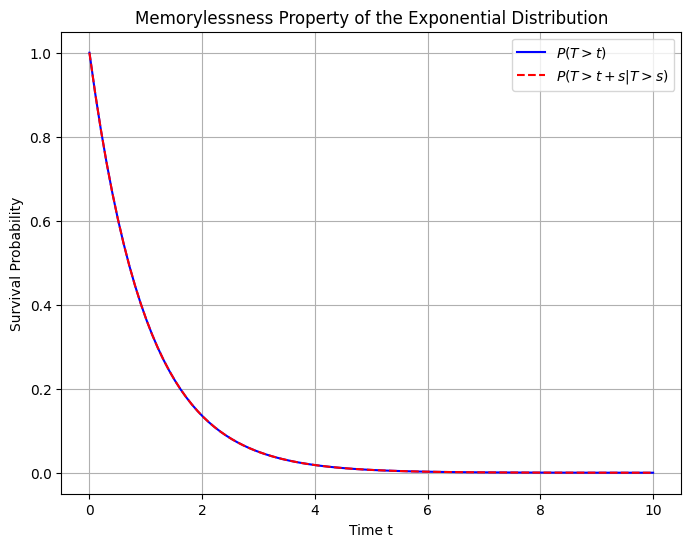

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

# Define the rate parameter (lambda)
lambda_param = 1.0

# Create a range of t values
t = np.linspace(0, 10, 100)

# Calculate the survival function P(T > t)
survival_function = np.exp(-lambda_param * t)

# Plot the survival function
plt.figure(figsize=(8, 6))
plt.plot(t, survival_function, label='$P(T > t)$', color='blue')

# Illustrate the memorylessness property
s = 50
survival_t_plus_s_given_s = np.exp(-lambda_param * (t + s)) / np.exp(-lambda_param * s)  # P(T > t + s | T > s)
plt.plot(t, survival_t_plus_s_given_s, label='$P(T > t + s | T > s)$', linestyle='--', color='red')

plt.xlabel('Time t')
plt.ylabel('Survival Probability')
plt.title('Memorylessness Property of the Exponential Distribution')
plt.legend()
plt.grid(True)
plt.figuresize=(8, 6)
plt.show()


## Is Gaussian distribution memoryless? 

<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
C:\Users\socks\AppData\Local\Temp\ipykernel_36308\3962325074.py:23: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x, survival_x_plus_s_given_s, label='$P(X > x + s \mid X > s)$', linestyle='--', color='red')


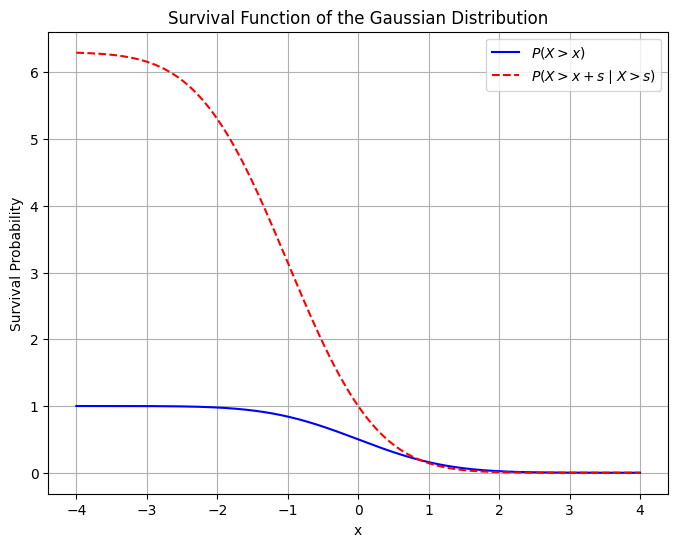

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define the mean and standard deviation
mean = 0
std_dev = 1.0

# Create a range of x values
x = np.linspace(mean - 4*std_dev, mean + 4*std_dev, 1000)

# Calculate the CDF and survival function
cdf = norm.cdf(x, loc=mean, scale=std_dev)
survival_function = 1 - cdf

# Plot the Gaussian survival function
plt.figure(figsize=(8, 6))
plt.plot(x, survival_function, label='$P(X>x)$', color='blue')

# Illustrate the comparison for memorylessness
s = 1
survival_x_plus_s_given_s = (1 - norm.cdf(x + s, loc=mean, scale=std_dev)) / (1 - norm.cdf(s, loc=mean, scale=std_dev))
plt.plot(x, survival_x_plus_s_given_s, label='$P(X > x + s \mid X > s)$', linestyle='--', color='red')

plt.xlabel('x')
plt.ylabel('Survival Probability')
plt.title('Survival Function of the Gaussian Distribution')
plt.legend()
plt.grid(True)
plt.show()


### Does the discrete Geometric process satisfy memorylessness? 

Comparing 
$$
P(T > k) = (1-p)^k
$$

and

$$
P(T > k+m \mid T > m)
= \frac{P(T > k+m)}{P(T > m)}
= \frac{(1-p)^{k+m}}{(1-p)^m}
= (1-p)^k.
$$


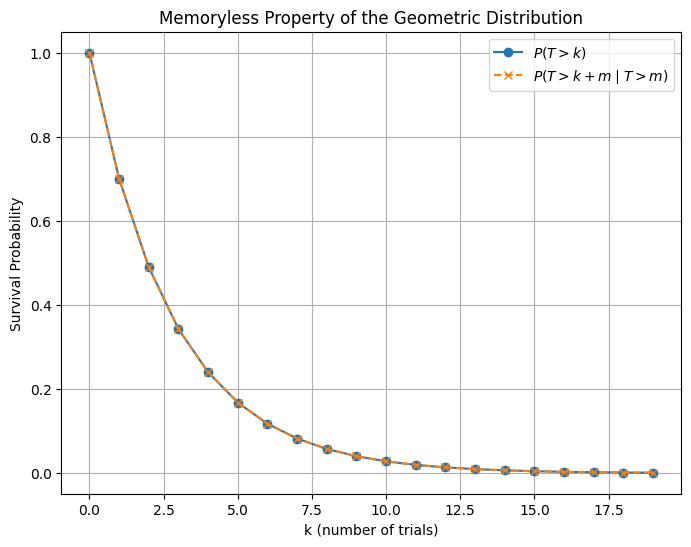

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Geometric parameter
p = 0.3

# Discrete k values (number of trials)
k = np.arange(0, 20)

# Survival function P(T > k)
survival_function = (1 - p) ** k

# Choose m (already waited trials)
m = 5

# Conditional survival P(T > k + m | T > m)
survival_k_plus_m_given_m = ((1 - p) ** (k + m)) / ((1 - p) ** m)

# Plot
plt.figure(figsize=(8,6))

plt.plot(k, survival_function, marker='o', label=r'$P(T>k)$')

plt.plot(
    k,
    survival_k_plus_m_given_m,
    linestyle='--',
    marker='x',
    label=r'$P(T>k+m \mid T>m)$'
)

plt.xlabel('k (number of trials)')
plt.ylabel('Survival Probability')
plt.title('Memoryless Property of the Geometric Distribution')

plt.legend()
plt.grid(True)

plt.show()